# FeatureDataset cache and sklearn export

A reproducible tutorial for loading configured EEG feature blocks, verifying modular disk-cache reuse, and exporting window-level rows with their parent sample metadata.

## Goal

Demonstrate the stage 4 public API on canonical key `(1, 1, 1)` from both `Data_Train/exec` and `Data_Pattern/patt`.

- Use six complete 5-second windows with a 2-second stride inside crop `[0.5, 15.5)`.
- Keep recording families in separate `FeatureDataset` and `FeatureMatrix` objects.
- Verify that a valid feature-cache hit does not load source EEG/EOG arrays.
- Export only `time`, `spectral`, and `lndp` blocks while retaining parent keys, window indices, and absolute bounds.

No scaling, PCA, feature selection, target construction, or ML split is performed here.

## Setup

The notebook uses the local repository, canonical FIF sources, and a temporary cache root so the first and second accesses have explicit cold/warm semantics.

In [1]:
import os
import sys
import tempfile
import time
import textwrap
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-eeg-feature-dataset")

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "pyproject.toml").is_file():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from features import build_feature_matrix, load_feature_config
from utils.datasets import FeatureDataset

TOKENS = {
    "surface": "#FCFCFD",
    "panel": "#FFFFFF",
    "ink": "#1F2430",
    "muted": "#6F768A",
    "grid": "#E6E8F0",
    "axis": "#D7DBE7",
}
COLORS = {
    "blue": {"base": "#A3BEFA", "dark": "#2E4780"},
    "gold": {"base": "#FFE15B", "dark": "#736422"},
    "orange": {"base": "#F0986E", "dark": "#804126"},
}
plt.rcParams.update({
    "figure.facecolor": TOKENS["surface"],
    "axes.facecolor": TOKENS["panel"],
    "axes.edgecolor": TOKENS["axis"],
    "axes.labelcolor": TOKENS["ink"],
    "grid.color": TOKENS["grid"],
    "font.family": "DejaVu Sans",
})

def add_chart_header(fig, ax, title, subtitle):
    title = textwrap.fill(title, width=78, break_long_words=False)
    subtitle = textwrap.fill(subtitle, width=110, break_long_words=False)
    ax.set_title("")
    fig.subplots_adjust(top=0.79)
    left = ax.get_position().x0
    fig.text(left, 0.97, title, ha="left", va="top", fontsize=13, fontweight="semibold", color=TOKENS["ink"])
    fig.text(left, 0.89, subtitle, ha="left", va="top", fontsize=9, color=TOKENS["muted"])
    ax.spines[["top", "right"]].set_visible(False)

CONFIG = load_feature_config(overrides={
    "window_seconds": 5.0,
    "window_stride_seconds": 2.0,
})
SAMPLE_KEY = (1, 1, 1)
SELECTED_BLOCKS = ("time", "spectral", "lndp")
CONFIG

FeatureExtractionConfig(analysis_sfreq=125.0, crop_start_seconds=0.5, crop_end_seconds=15.5, window_seconds=5.0, window_stride_seconds=2.0, dtype='float32', feature_groups=('time', 'spectral', 'spatial', 'local_patterns'), frequency_bands=(FrequencyBand(name='delta', f_min=2.0, f_max=4.0), FrequencyBand(name='theta', f_min=4.0, f_max=8.0), FrequencyBand(name='alpha', f_min=8.0, f_max=13.0), FrequencyBand(name='beta', f_min=13.0, f_max=30.0), FrequencyBand(name='low_gamma', f_min=30.0, f_max=40.0)), histogram_mode='probability', local_pattern_neighbors=8, transform_eog=False, filter_hz=None, notch_hz=None, reference=None, normalization='none')

## Steps

### 1. Build and reuse isolated feature caches

Each family receives a distinct cache path. After the first extraction, a new `FeatureDataset` instance is created and its source-array loader is replaced with a function that raises. Successful second access therefore proves that the feature cache is sufficient.

In [2]:
temporary_cache = tempfile.TemporaryDirectory(prefix="feature-dataset-notebook-")
cache_root = Path(temporary_cache.name)
dataset_specs = {
    "exec": PROJECT_ROOT / "data" / "Data_Train",
    "patt": PROJECT_ROOT / "data" / "Data_Pattern",
}

feature_sets = {}
cache_rows = []
cache_files = []

def fail_source_array_load(*args, **kwargs):
    raise AssertionError("A valid feature-cache hit must not load source EEG/EOG arrays")

for family, dataset_dir in dataset_specs.items():
    cold_dataset = FeatureDataset(
        dataset_dir,
        dataset_step_type=family,
        config=CONFIG,
        cache_dir=cache_root,
        source_cache_policy=None,
    )
    started = time.perf_counter()
    cold_feature_set = cold_dataset[SAMPLE_KEY]
    cold_seconds = time.perf_counter() - started

    warm_dataset = FeatureDataset(
        dataset_dir,
        dataset_step_type=family,
        config=CONFIG,
        cache_dir=cache_root,
        source_cache_policy=None,
    )
    warm_dataset.source_dataset._load_sample = fail_source_array_load
    started = time.perf_counter()
    warm_feature_set = warm_dataset[SAMPLE_KEY]
    warm_seconds = time.perf_counter() - started

    for cold_block, warm_block in zip(cold_feature_set.blocks, warm_feature_set.blocks, strict=True):
        np.testing.assert_array_equal(cold_block.values, warm_block.values)
    feature_sets[family] = warm_feature_set
    cache_entry = warm_dataset.get_cache_entry_path(SAMPLE_KEY)
    cache_rows.extend([
        {"family": family, "access": "First extraction", "seconds": max(cold_seconds, 1e-6)},
        {"family": family, "access": "Disk-cache hit", "seconds": max(warm_seconds, 1e-6)},
    ])
    cache_files.extend(
        {"family": family, "file": path.name, "size_kib": path.stat().st_size / 1024}
        for path in sorted(cache_entry.iterdir())
    )

cache_timing = pd.DataFrame(cache_rows)
cache_inventory = pd.DataFrame(cache_files)
cache_timing

,family,access,seconds
0,exec,First extraction,0.213843
1,exec,Disk-cache hit,0.001014
2,patt,First extraction,0.214854
3,patt,Disk-cache hit,0.000899


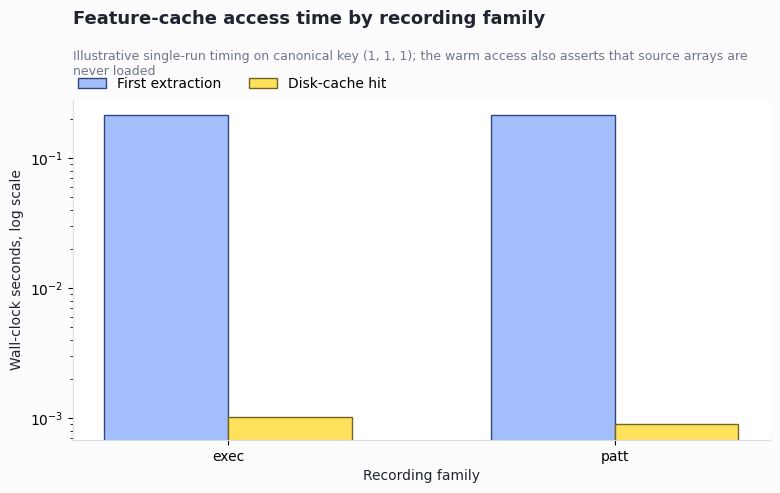

,family,file,size_kib
0,exec,correlation.npy,93.15
1,exec,covariance.npy,93.15
2,exec,lbp.npy,378.12
3,exec,lgp.npy,378.12
4,exec,lndp.npy,378.12
5,exec,log_covariance.npy,93.15
6,exec,manifest.json,20.28
7,exec,spectral.npy,20.80
8,exec,time.npy,19.32
9,exec,window_bounds_seconds.npy,0.22


In [3]:
fig, ax = plt.subplots(figsize=(9, 5))
families = list(dataset_specs)
x = np.arange(len(families))
width = 0.32
for offset, access, color, edge in (
    (-width / 2, "First extraction", COLORS["blue"]["base"], COLORS["blue"]["dark"]),
    (width / 2, "Disk-cache hit", COLORS["gold"]["base"], COLORS["gold"]["dark"]),
):
    values = (
        cache_timing.loc[cache_timing["access"] == access]
        .set_index("family")
        .loc[families, "seconds"]
        .to_numpy()
    )
    ax.bar(x + offset, values, width=width, label=access, color=color, edgecolor=edge, linewidth=1.0)
ax.set_xticks(x, families)
ax.set_yscale("log")
ax.set_xlabel("Recording family")
ax.set_ylabel("Wall-clock seconds, log scale")
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), frameon=False, ncol=2, borderaxespad=0)
ax.grid(axis="x", visible=False)
add_chart_header(
    fig,
    ax,
    "Feature-cache access time by recording family",
    "Illustrative single-run timing on canonical key (1, 1, 1); the warm access also asserts that source arrays are never loaded",
)
plt.show()

cache_inventory.groupby(["family", "file"], as_index=False)["size_kib"].sum().round(2)

### 2. Export selected blocks without mixing recording families

`build_feature_matrix(...)` accepts any dataset-like object that yields `FeatureSet`. A one-sample view keeps this demonstration bounded while exercising the same flattening and metadata contract used for a full family.

In [4]:
class OneFeatureSetDataset:
    def __init__(self, feature_set, recording_family):
        self.feature_set = feature_set
        self.dataset_step_type = recording_family

    def __len__(self):
        return 1

    def __getitem__(self, key):
        if key != 0:
            raise IndexError(key)
        return self.feature_set

exports = {
    family: build_feature_matrix(
        OneFeatureSetDataset(feature_set, family),
        block_names=SELECTED_BLOCKS,
    )
    for family, feature_set in feature_sets.items()
}

export_summary = pd.DataFrame([
    {
        "family": family,
        "rows": exported.X.shape[0],
        "columns": exported.X.shape[1],
        "dtype": exported.X.dtype.name,
        "first_feature": exported.feature_names[0],
        "last_feature": exported.feature_names[-1],
    }
    for family, exported in exports.items()
])
export_summary

,family,rows,columns,dtype,first_feature,last_feature
0,exec,6,17829,float32,time:Fp1:mean,lndp:Iz:code_255
1,patt,6,17829,float32,time:Fp1:mean,lndp:Iz:code_255


In [5]:
metadata_rows = []
for family, exported in exports.items():
    for row_index, (sample_key, window_index, bounds) in enumerate(
        zip(exported.sample_keys, exported.window_indices, exported.window_bounds_seconds, strict=True)
    ):
        metadata_rows.append({
            "family": family,
            "matrix_row": row_index,
            "sample_key": sample_key,
            "window_index": int(window_index),
            "window_start_s": bounds[0],
            "window_end_s": bounds[1],
        })
metadata = pd.DataFrame(metadata_rows)
metadata

,family,matrix_row,sample_key,window_index,window_start_s,window_end_s
0,exec,0,"(1, 1, 1)",0,0.5,5.5
1,exec,1,"(1, 1, 1)",1,2.5,7.5
2,exec,2,"(1, 1, 1)",2,4.5,9.5
3,exec,3,"(1, 1, 1)",3,6.5,11.5
4,exec,4,"(1, 1, 1)",4,8.5,13.5
5,exec,5,"(1, 1, 1)",5,10.5,15.5
6,patt,0,"(1, 1, 1)",0,0.5,5.5
7,patt,1,"(1, 1, 1)",1,2.5,7.5
8,patt,2,"(1, 1, 1)",2,4.5,9.5
9,patt,3,"(1, 1, 1)",3,6.5,11.5


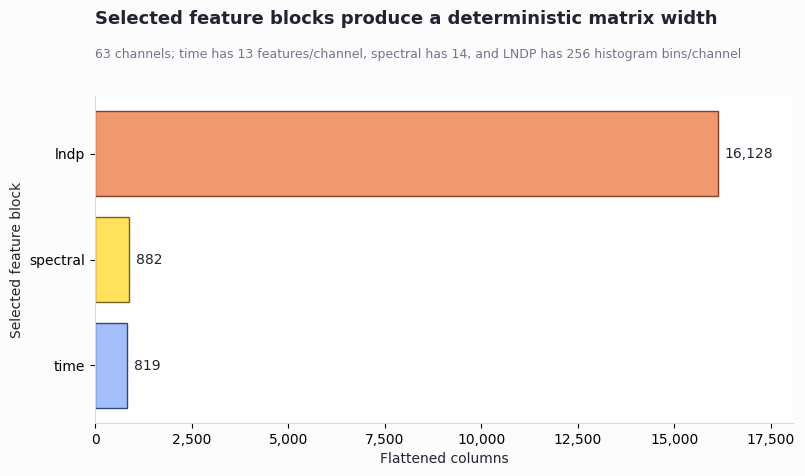

,block,columns
0,lndp,16128
1,spectral,882
2,time,819


In [6]:
feature_names = exports["patt"].feature_names
block_counts = pd.Series([name.split(":", maxsplit=1)[0] for name in feature_names]).value_counts()
block_count_table = block_counts.rename_axis("block").reset_index(name="columns")

fig, ax = plt.subplots(figsize=(9, 4.8))
plot_table = block_count_table.sort_values("columns", ascending=True)
bar_colors = {
    "time": COLORS["blue"]["base"],
    "spectral": COLORS["gold"]["base"],
    "lndp": COLORS["orange"]["base"],
}
edge_colors = {
    "time": COLORS["blue"]["dark"],
    "spectral": COLORS["gold"]["dark"],
    "lndp": COLORS["orange"]["dark"],
}
bars = ax.barh(
    plot_table["block"],
    plot_table["columns"],
    color=[bar_colors[name] for name in plot_table["block"]],
    edgecolor=[edge_colors[name] for name in plot_table["block"]],
    linewidth=1.0,
)
for bar, value in zip(bars, plot_table["columns"], strict=True):
    ax.text(value + 180, bar.get_y() + bar.get_height() / 2, f"{value:,}", va="center", color=TOKENS["ink"])
ax.set_xlabel("Flattened columns")
ax.set_ylabel("Selected feature block")
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.grid(axis="y", visible=False)
ax.set_xlim(0, plot_table["columns"].max() * 1.12)
add_chart_header(
    fig,
    ax,
    "Selected feature blocks produce a deterministic matrix width",
    "63 channels; time has 13 features/channel, spectral has 14, and LNDP has 256 histogram bins/channel",
)
plt.show()
block_count_table

## Checks

The checks below protect the scientific grain: six rows are windows, but all six retain one parent block key. `exec` and `patt` remain separate exports even though their selected feature names are identical.

In [7]:
for family, exported in exports.items():
    assert exported.recording_family == family
    assert exported.X.shape == (6, 17_829)
    assert exported.X.dtype == np.dtype(np.float32)
    assert np.isfinite(exported.X).all()
    assert exported.sample_keys == (SAMPLE_KEY,) * 6
    np.testing.assert_array_equal(exported.window_indices, np.arange(6))
    np.testing.assert_array_equal(
        exported.window_bounds_seconds[[0, -1]],
        [[0.5, 5.5], [10.5, 15.5]],
    )
assert exports["exec"].feature_names == exports["patt"].feature_names
assert cache_timing.shape == (4, 3)
assert set(cache_inventory["file"]) >= {
    "manifest.json",
    "window_bounds_seconds.npy",
    "time.npy",
    "spectral.npy",
    "covariance.npy",
    "correlation.npy",
    "log_covariance.npy",
    "lndp.npy",
    "lgp.npy",
    "lbp.npy",
}
print("FEATURE_DATASET_EXPORT_VERIFIED")

FEATURE_DATASET_EXPORT_VERIFIED


## Next Steps

Use `sample_keys` or subject IDs to define grouped folds before any learned transformation. Fit scaling, PCA, feature selection, and models only inside each training fold. Do not treat the six windows from one block as independent split units.